# LAB 7: Foundational Models in Sequence Classification

In this lab, we will compare two approaches for **sequence classification** on multi-lead ECG signals:

- a **pretrained sequence model** based on `roberta-base`, adapted to ECG through a fixed synthetic-token pipeline
- a **compact 1D CNN baseline** trained directly on raw beat windows

We will explore how a **foundation model** can be adapted to a new sequence domain and compared against a simpler non-pretrained baseline under the same validation protocol.

This lab uses the St. Petersburg INCART 12-lead Arrhythmia Database (https://physionet.org/content/incartdb/1.0.0/v). Download the student data bundle from the OneDrive link below rather than from the original PhysioNet website:

https://livejohnshopkins-my.sharepoint.com/:u:/g/personal/ywang792_jh_edu/IQBWQ322R9-QS665JSLhbmSLAbGkWidMtxO3RipgITtVdf8?e=hF7how

The downloaded dataset contains a **public labeled subset** and a **hidden signals only subset** for the bonus task. The hidden folder in the student bundle contains ECG signals and beat indices, but **not** labels. Hidden labels are kept private and are used only by Gradescope for bonus-task scoring and leaderboard evaluation (which means you shouldn't have to touch it). If you use the original full dataset instead of the provided student bundle, points will be deducted and your bonus task will be disregarded.


## Runtime Notes

**NOTE 1:** GPU is required for this lab. Use a Colab GPU runtime.

**NOTE 2:** This notebook is scoped for limited GPU access.

Use the following runtime-control rules:
- exactly **3-fold** patient-level cross-validation
- **no grid search**
- low epoch counts for both models
- expected total runtime is roughly **1 to 2 hours** on a Colab A100 GPU.

**NOTE 3:** The default setting uses **2 ECG leads**.

**NOTE 4:** Display all requested outputs in your completed notebook.


## Library Imports


In [1]:
# Install the packages you need for this lab.
# You may need to run this cell again after restarting the Colab runtime.
import subprocess
import sys

subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "wfdb", "transformers"])


0

In [2]:
# Please feel free to add more libraries if needed.
import copy
import itertools
import os
import random
import urllib.request
from collections import OrderedDict
from pathlib import Path
from types import SimpleNamespace

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import wfdb
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from torch.cuda.amp import GradScaler, autocast
from torch.utils.data import DataLoader, Dataset
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from tqdm.notebook import tqdm
import scipy.signal


In [3]:
# Runtime and checkpoint setup.
CHECKPOINT_DIR = Path("lab7_checkpoints")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_PATH = CHECKPOINT_DIR / "lab7_best_roberta_checkpoint.pt"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cpu


## Task 1: Explore INCART and Label Definitions (5 points)

In this task, we will load the public INCART subset, inspect one record, and confirm the labeling rules that will be used throughout the lab.

Use the following task-specific settings:
- `SEED = 7` for reproducibility
- `FS = 257` samples/second
- `PRE_S = 0.25` seconds before the beat
- `POST_S = 0.45` seconds after the beat
- `WINDOW_SIZE = 181` samples per beat window
- `DEFAULT_LEADS = ["I", "II"]`

We have provided the code to prepare and visualize dataset, since it is similiar to Lab3.

**1.1. Download the dataset** (0 points)

Download the student data bundle from the OneDrive link given at the top of the notebook.

Then upload the zip file manually to the current working directory of Colab's runtime. The uploaded file must be named exactly:
- `incart_data_MLMA_2025_Student.zip`

After unzipping, the bundle should contain:
- `incart_dataset_MLMA_2026/` for the public labeled set
- `hidden_incart_MLMA_2026/` for the hidden signals and hidden beat indices used in the bonus task

The hidden folder is **not** for supervised training. It is only used later to generate a prediction file for Gradescope.


In [9]:
SEED = 7
FS = 257			
PRE_S = 0.25			
POST_S = 0.45		
WINDOW_SIZE = int(round(PRE_S * FS)) + int(round(POST_S * FS)) + 1
DEFAULT_LEADS = ["I", "II"]

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Sampling rate (FS):", FS)
print("Beat window length (samples):", WINDOW_SIZE)
print("Default leads:", DEFAULT_LEADS)

NOTEBOOK_DIR = Path.cwd()
ARCHIVE_PATH = NOTEBOOK_DIR / "incart_data_MLMA_2025_Student.zip"
BUNDLE_ROOT = NOTEBOOK_DIR / "incart_data_MLMA_2025_Student"
DATASET_ROOT = BUNDLE_ROOT / "incart_dataset_MLMA_2026"
HIDDEN_SIGNAL_ROOT = BUNDLE_ROOT / "hidden_incart_MLMA_2026"
HIDDEN_BEAT_INDEX_PATH = HIDDEN_SIGNAL_ROOT / "hidden_beat_indices.csv"
if not ARCHIVE_PATH.exists():
    raise FileNotFoundError(
        "Could not find 'incart_data_MLMA_2025_Student.zip' in the current working directory. "
        "Please download it from the OneDrive link in the notebook and upload it to the Colab runtime."
    )
else:
    print("Found uploaded archive:", ARCHIVE_PATH)

marker_path = BUNDLE_ROOT / ".unzipped"
if not marker_path.exists():
    print("Unzipping student data bundle...")
    os.system(f'unzip -qo "{ARCHIVE_PATH}" -d "{NOTEBOOK_DIR}"')
    marker_path.write_text("ok")
else:
    print("Student data bundle already unzipped.")

if not DATASET_ROOT.exists() or not HIDDEN_SIGNAL_ROOT.exists():
    raise FileNotFoundError("Expected student bundle folders were not found after unzip. Please check the uploaded zip structure.")

print("Public dataset root:", DATASET_ROOT)
print("Hidden-signal root:", HIDDEN_SIGNAL_ROOT)
print("Hidden beat-index file:", HIDDEN_BEAT_INDEX_PATH)


Sampling rate (FS): 257
Beat window length (samples): 181
Default leads: ['I', 'II']
Found uploaded archive: /home/kahl/codes/ai/machine_learning/medical_applications/labs/lab7/incart_data_MLMA_2025_Student.zip
Student data bundle already unzipped.
Public dataset root: /home/kahl/codes/ai/machine_learning/medical_applications/labs/lab7/incart_data_MLMA_2025_Student/incart_dataset_MLMA_2026
Hidden-signal root: /home/kahl/codes/ai/machine_learning/medical_applications/labs/lab7/incart_data_MLMA_2025_Student/hidden_incart_MLMA_2026
Hidden beat-index file: /home/kahl/codes/ai/machine_learning/medical_applications/labs/lab7/incart_data_MLMA_2025_Student/hidden_incart_MLMA_2026/hidden_beat_indices.csv


In [10]:
ABNORMAL = {"L", "R", "V", "/", "A", "f", "F", "j", "a", "E", "J", "e", "S"}


def find_incart_records_dir(dataset_root: Path) -> Path:
    for root, _, files in os.walk(dataset_root):
        if "files-patients-diagnoses.txt" in files:
            return Path(root)
    raise FileNotFoundError("Could not find files-patients-diagnoses.txt inside the INCART download.")


RECORDS_DIR = find_incart_records_dir(DATASET_ROOT)
print("Resolved records directory:", RECORDS_DIR)


def load_ECG_file(path, lead=None):
    # Input:
    #   path: Path to the patient file (excluding extension)
    #   lead: Optional lead index or lead name. If None, use lead I / first lead.
    # Output:
    #   signal: ECG signal for the chosen lead
    #   symbol: Annotation symbols
    #   index: Annotation sample positions
    #   lead_names: Available lead names in the record
	
	# read the ECG record and annotations using wfdb
    record = wfdb.rdrecord(str(path))

	# Read the annotation for the record
    annotation = wfdb.rdann(str(path), "atr")
	
	# Get the list of lead names from the record
    lead_names = list(record.sig_name)

    if lead is None:
        lead_index = 0
    elif isinstance(lead, str):
        lead_index = lead_names.index(lead)
    else:
        lead_index = int(lead)

    signal = record.p_signal[:, lead_index]
    symbol = annotation.symbol
    index = annotation.sample
    return signal, symbol, index, lead_names


example_record = RECORDS_DIR / "I48"
signal, symbol, index, lead_names = load_ECG_file(example_record)
print(f"Example record: {example_record.name}")
print(f"Available leads: {lead_names}")
print(f"Signal length: {len(signal)} samples")
print(f"First 20 annotation symbols: {symbol[:20]}")
print(f"First 20 annotation indices: {index[:20]}")


Resolved records directory: /home/kahl/codes/ai/machine_learning/medical_applications/labs/lab7/incart_data_MLMA_2025_Student/incart_dataset_MLMA_2026
Example record: I48
Available leads: ['I', 'II', 'III', 'AVR', 'AVL', 'AVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
Signal length: 462600 samples
First 20 annotation symbols: ['N', 'N', 'N', 'N', 'N', 'V', 'N', 'N', 'N', 'V', 'N', 'N', 'N', 'V', 'N', 'N', 'N', 'V', 'N', 'N']
First 20 annotation indices: [ 209  446  676  906 1102 1231 1555 1778 1979 2110 2339 2528 2740 2873
 3158 3361 3542 3676 3892 4071]


**1.2. Visualize the signal and annotation structure** (0 points)

Plot:
- a random 10-second region from the example ECG file
- a 1-second region centered on an abnormal beat

Then answer the short questions below.


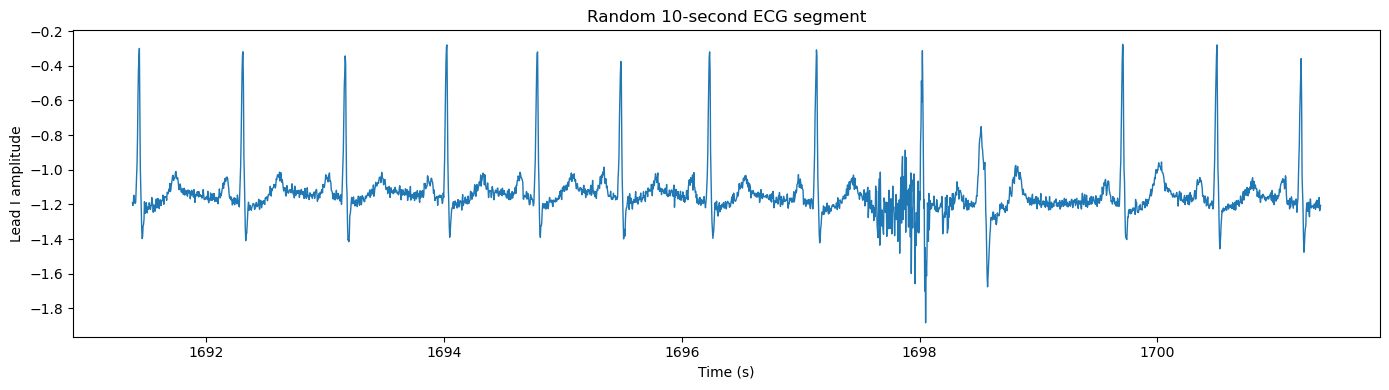

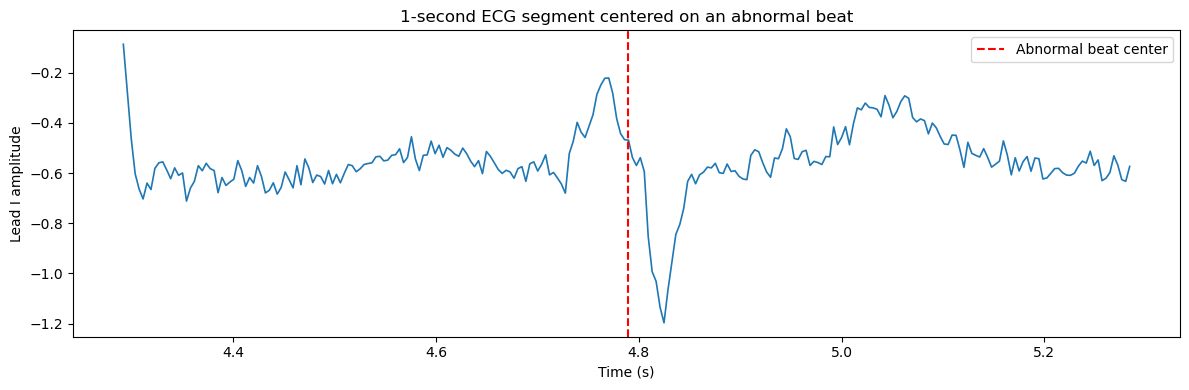

N    2119
V     235
A       2
F       1
Name: count, dtype: int64


In [11]:
rng = np.random.default_rng(SEED)
window_10s = 10 * FS
start_10s = int(rng.integers(0, len(signal) - window_10s))
end_10s = start_10s + window_10s

t = np.arange(start_10s, end_10s) / FS
plt.figure(figsize=(14, 4))
plt.plot(t, signal[start_10s:end_10s], linewidth=1)
plt.xlabel("Time (s)")
plt.ylabel("Lead I amplitude")
plt.title("Random 10-second ECG segment")
plt.tight_layout()
plt.show()

abnormal_positions = [idx for sym, idx in zip(symbol, index) if sym in ABNORMAL]
center = int(abnormal_positions[0])
half_window = FS // 2
start_1s = center - half_window
end_1s = center + half_window

t_zoom = np.arange(start_1s, end_1s) / FS
plt.figure(figsize=(12, 4))
plt.plot(t_zoom, signal[start_1s:end_1s], linewidth=1.2)
plt.axvline(center / FS, color="red", linestyle="--", label="Abnormal beat center")
plt.xlabel("Time (s)")
plt.ylabel("Lead I amplitude")
plt.title("1-second ECG segment centered on an abnormal beat")
plt.legend()
plt.tight_layout()
plt.show()

label_counts = pd.Series(symbol).value_counts().head(15)
print(label_counts)


**Task 1 answers** (5 points)

1. What should happen to all other symbols that are neither `N` nor in the abnormal set?

Answer: 

	They should be skipped or completely disregarded. Because the objective is to train a binary classifier to distinguish specifically between Normal (N) and Abnormal beats, any other symbols are unhelpful for this task and must be excluded from the dataset.
2. With the beat window used in this lab, how many samples are extracted per beat?

Answer:

	The window consists of 0.25 seconds before the beat and 0.45 seconds after the beat at a sampling frequency of 257 samples/second. This equates to 64 samples + 116 samples + 1 center beat sample = 181 total samples
Answer:


## Task 2: Build Beat-Window Datasets and Patient-Level Cross-Validation (20 points)

In this task, we will create beat-level examples and then split them at the **patient level** using a fixed 3-fold cross-validation protocol.

Use the following task-specific settings:
- `N_FOLD = 3`
- `BATCH_SIZE = 64`
- `NUM_WORKERS = 2`

**2.1. Read the patient-to-file metadata and construct folds** (10 points)


In [16]:
!ls 
print("\nContents of the dataset root:")
!ls incart_data_MLMA_2025_Student/incart_dataset_MLMA_2026/

incart_data_MLMA_2025_Student
incart_data_MLMA_2025_Student.zip
lab7_checkpoints
Lab7_FoundationalModels_SequenceClassification.ipynb
__MACOSX

Contents of the dataset root:
ANNOTATORS		      I19.hea  I36.atr	I58.dat
files-patients-diagnoses.txt  I20.atr  I36.dat	I58.hea
I01.atr			      I20.dat  I36.hea	I59.atr
I01.dat			      I20.hea  I37.atr	I59.dat
I01.hea			      I21.atr  I37.dat	I59.hea
I02.atr			      I21.dat  I37.hea	I60.atr
I02.dat			      I21.hea  I40.atr	I60.dat
I02.hea			      I22.atr  I40.dat	I60.hea
I06.atr			      I22.dat  I40.hea	I61.atr
I06.dat			      I22.hea  I41.atr	I61.dat
I06.hea			      I23.atr  I41.dat	I61.hea
I07.atr			      I23.dat  I41.hea	I62.atr
I07.dat			      I23.hea  I42.atr	I62.dat
I07.hea			      I24.atr  I42.dat	I62.hea
I08.atr			      I24.dat  I42.hea	I63.atr
I08.dat			      I24.hea  I43.atr	I63.dat
I08.hea			      I27.atr  I43.dat	I63.hea
I09.atr			      I27.dat  I43.hea	I64.atr
I09.dat			      I27.hea  I47.atr	I64.dat
I09.hea			      I28.atr  I47.da

In [57]:
N_FOLD = 3

from typing import Dict, List, Union
# start by reading the metadata and build a dictionary mapping patient ID to diagnosis
def read_incart_metadata(records_dir, meta_filename="files-patients-diagnoses.txt"):
	unique_patients = set()
	patient_info: Dict[int, Dict[str, Union[int, str, List[str]]]] = {}
	last_id = -1
	with open(RECORDS_DIR / "files-patients-diagnoses.txt", "r") as f:
		for line in f:
			# remove whitespace
			line = line.strip()
	
			if line == "":
				continue
			# check if the line starts with patient
			if line.startswith("patient"):

				# record patient id into the dictionary with diagnosis "unknown"
				patient_id = int(line.split()[1])
				
				last_id = patient_id
				if (patient_id not in unique_patients):

					# Found new patient
					unique_patients.add(patient_id)
					
					# Create a placeholder for the patient info
					info = {"files": [], "diagnosis": "unknown"}
					patient_info[patient_id] = info
			elif (line.startswith("I")):
				# record file name for the current patient
				file_name = line.split()
				patient_info[last_id]["files"].extend(file_name)
			
			else:
				# Record the patient description
				patient_info[last_id]["diagnosis"] = line

		return patient_info, unique_patients





def make_incart_cv_splits(records_dir, n_fold=3, seed=SEED, meta_filename="files-patients-diagnoses.txt"):
	# Read metadata
	patient_info, unique_patients = read_incart_metadata(records_dir, meta_filename)
	
	#  Create a Numpy array of patient IDs and shuffle it
	patient_ids = np.array(sorted(list(unique_patients)))
	rng = np.random.default_rng(seed)
	rng.shuffle(patient_ids) 
	
	#  Split the shuffled array into n_fold chunks
	chunks = np.array_split(patient_ids, n_fold)
	
	cv_splits = []

	#  Assign roles for each fold
	for i in range(n_fold):
		test_idx = i
		val_idx = (i + 1) % n_fold
	
		# Convert NumPy arrays back to standard Python lists
		test_patients = chunks[test_idx].tolist()
		val_patients = chunks[val_idx].tolist()
		
		# train gets all the remaining chunks
		train_patients = []
		for j in range(n_fold):
			if j != test_idx and j != val_idx:
				train_patients.extend(chunks[j].tolist())
				
		#  gather the corresponding ECG file names for each group
		train_files = []
		for p in train_patients:
			train_files.extend(patient_info[p]["files"])
			
		val_files = []
		for p in val_patients:
			val_files.extend(patient_info[p]["files"])
			
		test_files = []
		for p in test_patients:
			test_files.extend(patient_info[p]["files"])
			
		# Build the dictionary for this specific fold
		cv_splits.append({
			"fold": i,
			"train": {"patients": train_patients, "files": train_files},
			"val": {"patients": val_patients, "files": val_files},
			"test": {"patients": test_patients, "files": test_files}
		})
		
	return cv_splits, patient_info, unique_patients
	



cv_splits, patient_info, unique_patients = make_incart_cv_splits(RECORDS_DIR, n_fold=N_FOLD, seed=SEED)

print(unique_patients)
print("Number of patients in INCART metadata:", len(patient_info))
print("First 5 patient IDs:", list(sorted(patient_info))[:5])
print("\nCross-validation splits:")

for split in cv_splits:
	train_p = set(split["train"]["patients"])
	val_p = set(split["val"]["patients"])
	test_p = set(split["test"]["patients"])
	assert train_p.isdisjoint(val_p)
	assert train_p.isdisjoint(test_p)
	assert val_p.isdisjoint(test_p)
	print(
		f"Fold {split['fold']}: "
		f"train={len(train_p)} patients, val={len(val_p)} patients, test={len(test_p)} patients"
	)
	print(split["train"]["files"])


{1, 3, 4, 5, 6, 7, 9, 10, 11, 13, 14, 15, 16, 18, 19, 21, 22, 23, 25, 26, 27, 29, 31, 32}
Number of patients in INCART metadata: 24
First 5 patient IDs: [1, 3, 4, 5, 6]

Cross-validation splits:
Fold 0: train=8 patients, val=8 patients, test=8 patients
['I49', 'I50', 'I15', 'I74', 'I75', 'I62', 'I63', 'I64', 'I08', 'I68', 'I69', 'I27', 'I28', 'I33', 'I34']
Fold 1: train=8 patients, val=8 patients, test=8 patients
['I47', 'I48', 'I12', 'I13', 'I14', 'I57', 'I58', 'I09', 'I10', 'I11', 'I42', 'I43', 'I35', 'I36', 'I37', 'I29', 'I30', 'I31', 'I32', 'I01', 'I02']
Fold 2: train=8 patients, val=8 patients, test=8 patients
['I59', 'I60', 'I61', 'I51', 'I52', 'I53', 'I23', 'I24', 'I20', 'I21', 'I22', 'I06', 'I07', 'I72', 'I73', 'I40', 'I41', 'I18', 'I19']


**2.2. Build beat-centered datasets** (10 points)

Each example in this lab is one beat-centered ECG window. A beat is labeled:
- `0` if the symbol is `N`
- `1` if the symbol is in the abnormal set
- skipped otherwise

Boundary-overflow windows must be excluded.

Use `BATCH_SIZE = 64` and `NUM_WORKERS = 2` for the dataloaders in this task.


In [56]:
BATCH_SIZE = 64
NUM_WORKERS = 2

class BeatWindowDataset(Dataset):
	def __init__(self, records_dir, file_list, leads=DEFAULT_LEADS, transform=None, patient_info=None):
		self.records_dir = records_dir
		self.file_list = file_list
		self.leads = leads
		self.transform = transform
		self.patient_info = patient_info
	
	def __len__(self):
		return len(self.file_list)

	def __getitem__(self, idx):
		record_name = self.file_list[idx]
		record_path = self.records_dir / record_name
		
		# Read the ECG file from disk and extract the signal, annotation symbols, annotation indices, and lead names
		signal, symbol, index, lead_names = load_ECG_file(record_path, lead=self.leads[0])
		return signal, symbol, index, lead_names, record_name


def make_dataloaders_for_split(
records_dir,
split,
batch_size=BATCH_SIZE,
num_workers=NUM_WORKERS,
leads=DEFAULT_LEADS,
transform=None,
train_shuffle=True,
dataset_kwargs=None,
):
	train_ds = BeatWindowDataset(records_dir, split["train"]["files"], leads=leads, transform=transform, patient_info=patient_info)
	val_ds = BeatWindowDataset(records_dir, split["val"]["files"], leads=leads, transform=transform, patient_info=patient_info)
	test_ds = BeatWindowDataset(records_dir, split["test"]["files"], leads=leads, transform=transform, patient_info=patient_info)

	train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=train_shuffle, num_workers=num_workers)
	val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers)
	test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers)

	return train_ds, val_ds, test_ds, train_loader, val_loader, test_loader


fold0 = cv_splits[0]
print(fold0)
train_ds, val_ds, test_ds, train_loader, val_loader, test_loader = make_dataloaders_for_split(
RECORDS_DIR,
fold0,
leads=DEFAULT_LEADS,
)

x_batch, y_batch = next(iter(train_loader))
print("Raw training batch shape:", x_batch.shape)
print("Raw label batch shape:", y_batch.shape)
print("Fold 0 example counts:", len(train_ds), len(val_ds), len(test_ds))


{'fold': 0, 'train': {'patients': [22, 7, 32, 27, 4, 29, 13, 15], 'files': ['I49', 'I50', 'I15', 'I74', 'I75', 'I62', 'I63', 'I64', 'I08', 'I68', 'I69', 'I27', 'I28', 'I33', 'I34']}, 'val': {'patients': [26, 23, 11, 10, 3, 31, 18, 9], 'files': ['I59', 'I60', 'I61', 'I51', 'I52', 'I53', 'I23', 'I24', 'I20', 'I21', 'I22', 'I06', 'I07', 'I72', 'I73', 'I40', 'I41', 'I18', 'I19']}, 'test': {'patients': [21, 6, 25, 5, 19, 16, 14, 1], 'files': ['I47', 'I48', 'I12', 'I13', 'I14', 'I57', 'I58', 'I09', 'I10', 'I11', 'I42', 'I43', 'I35', 'I36', 'I37', 'I29', 'I30', 'I31', 'I32', 'I01', 'I02']}}


RuntimeError: Caught RuntimeError in DataLoader worker process 0.
Original Traceback (most recent call last):
  File "/home/kahl/anaconda3/envs/ml/lib/python3.12/site-packages/torch/utils/data/_utils/worker.py", line 349, in _worker_loop
    data = fetcher.fetch(index)  # type: ignore[possibly-undefined]
           ^^^^^^^^^^^^^^^^^^^^
  File "/home/kahl/anaconda3/envs/ml/lib/python3.12/site-packages/torch/utils/data/_utils/fetch.py", line 55, in fetch
    return self.collate_fn(data)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/home/kahl/anaconda3/envs/ml/lib/python3.12/site-packages/torch/utils/data/_utils/collate.py", line 398, in default_collate
    return collate(batch, collate_fn_map=default_collate_fn_map)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/kahl/anaconda3/envs/ml/lib/python3.12/site-packages/torch/utils/data/_utils/collate.py", line 212, in collate
    collate(samples, collate_fn_map=collate_fn_map)
  File "/home/kahl/anaconda3/envs/ml/li

## Task 3: Adapt a Pretrained Sequence Model to ECG (30 points)

In this task, we will convert each beat window into a **fixed synthetic token sequence** so that a pretrained sequence model can operate on ECG windows.

A pretrained sequence model expects a sequence of **discrete IDs**, not a short continuous-valued ECG waveform. Our goal in Task 3 is therefore to build a step-by-step pipeline that turns a beat window from a real-valued signal into a compact discrete representation that the pretrained model can process.

Use the following task-specific settings:
- `ROBERTA_MODEL_NAME = "roberta-base"`
- `TOKEN_ID_OFFSET = 1000`
- `CLIP_Z = 3.0`

The overall idea is:
1. stabilize the raw ECG values so they are easier to compare across leads and beats
2. reduce the temporal resolution to obtain a shorter, smoother representation
3. discretize the processed values into a finite set of signal symbols
4. map those signal symbols into valid token IDs for the pretrained model

By the end of Task 3, each beat window will be represented by `input_ids` and an `attention_mask`, just like a standard sequence-model input.


### Task 3.1. Per-lead z-score normalization (5 points)
Normalize each ECG lead independently within the beat window.

This step is needed because different ECG leads can have different baselines and amplitude ranges even within the same patient record. If we directly quantize raw amplitudes, those lead-specific differences can dominate the representation and make the tokenization unstable.

Per-lead z-score normalization centers each lead around zero and rescales it by its own standard deviation. After this step, the model focuses more on **waveform shape** and less on absolute amplitude differences that are not central to the classification task.


In [ ]:
def zscore_per_lead(x: torch.Tensor):
    # TODO


task3_example_x, task3_example_y = train_ds[0]
task3_step1 = zscore_per_lead(task3_example_x)
print("Task 3.1 output shape:", task3_step1.shape)
print("Task 3.1 per-lead means:", task3_step1.mean(dim=1))
print("Task 3.1 per-lead stds:", task3_step1.std(dim=1))


### Task 3.2. Low-pass filtering and downsampling (5 points)
Reduce the temporal resolution by first smoothing the signal with a low-pass filter and then downsampling it.

This step is used to create a shorter and cleaner sequence representation before the signal is converted into discrete symbols. The low-pass filtering stage smooths rapid local fluctuations, and the downsampling stage keeps a lower-resolution version of the waveform.

In this lab, we use the built-in `scipy.signal.decimate(...)` function. This function applies an anti-aliasing low-pass filter and then downsamples the signal.


In [ ]:
def lowpass_and_downsample(x: torch.Tensor, downsample_factor: int):
    # TODO


task3_step2 = lowpass_and_downsample(task3_step1, downsample_factor=4)
print("Task 3.2 output shape:", task3_step2.shape)
print("Task 3.2 first 5 downsampled values:\n", task3_step2[:, :5])


### Task 3.3. Clipping as a pre-quantization robustness step (5 points)
Clip the downsampled signal values to a fixed interval before quantization.

Why is this useful?
- even after normalization and downsampling, a small number of values may still be unusually large or small
- those extreme values can stretch the dynamic range and waste quantization bins
- clipping keeps the representation focused on the value range where most informative ECG variation occurs

So the purpose of Task 3.3 is to make the later discretization step more stable.


In [ ]:
CLIP_Z = 3.0

def clip_signal_values(x: torch.Tensor, clip_z: float = CLIP_Z):
    # TODO


task3_step3 = clip_signal_values(task3_step2, clip_z=CLIP_Z)
print("Task 3.3 output shape:", task3_step3.shape)
print("Task 3.3 min/max:", float(task3_step3.min()), float(task3_step3.max()))


### Task 3.4. Uniform quantization (5 points)
Map the clipped values into a fixed number of quantization bins.

After clipping, the signal is still continuous-valued. In this step, we convert each patched value into a discrete bin index such as `0, 1, 2, ..., K-1`.

These bin indices are the first true **signal symbols** in the pipeline. At this point, we have not yet produced valid model token IDs. We have only converted the continuous ECG values into a finite discrete alphabet.


In [ ]:
def uniform_quantize(x: torch.Tensor, quant_levels: int, clip_z: float = CLIP_Z):
    # TODO


task3_step4 = uniform_quantize(task3_step3, quant_levels=50, clip_z=CLIP_Z)
print("Task 3.4 output shape:", task3_step4.shape)
print("Task 3.4 unique bins sample:", torch.unique(task3_step4)[:10])


### Task 3.5. Token ID offset (5 points)
Shift the quantized bin indices into a valid token-ID range for the pretrained tokenizer.

This step is extremely important.

After Task 3.4, each patched ECG value has become a discrete bin index, for example:
- quantized bins: `[1, 2, 4]`

These are now **signal symbols**, but they are not yet valid inputs for `roberta-base`. The pretrained model expects token IDs that lie inside its tokenizer vocabulary. We therefore shift the quantized bin indices into a safe region of the token-ID space.

For example, if the token ID offset is `1000`, then:
- quantized bins: `[1, 2, 4]`
- token IDs after offset: `[1001, 1002, 1004]`

So Task 3.5 is not doing another round of quantization. It is doing a **mapping from discrete signal symbols to valid model token IDs**.

This is analogous to text processing:
- in NLP, words or subwords are mapped to token IDs
- in this lab, quantized ECG bins are mapped to token IDs

The offset is used so that the new ECG-derived IDs do not collide with special tokens or other reserved IDs used by the pretrained model.


In [ ]:
ROBERTA_MODEL_NAME = "roberta-base"
TOKEN_ID_OFFSET = 1000

tokenizer = AutoTokenizer.from_pretrained(ROBERTA_MODEL_NAME, use_fast=True)

def apply_token_id_offset(q: torch.Tensor, quant_levels: int, token_id_offset: int = TOKEN_ID_OFFSET, tokenizer=tokenizer):
    # TODO


task3_step5 = apply_token_id_offset(task3_step4, quant_levels=50, token_id_offset=TOKEN_ID_OFFSET, tokenizer=tokenizer)
print("Task 3.5 token vector length:", task3_step5.shape[0])
print("Task 3.5 first 20 token IDs:", task3_step5[:20])


### Task 3.6. Special tokens and padding/truncation (5 points)
Add the required special tokens and construct a fixed-length `input_ids` / `attention_mask` pair.

Once the ECG-derived token IDs have been created, we still need to package them in the format expected by the pretrained sequence model.

This includes:
- adding the required boundary or special tokens
- truncating sequences that are too long
- padding sequences that are shorter than the target length
- building an `attention_mask` so the model knows which positions are real data and which are padding

After this step, the ECG beat window has been fully converted into a standard sequence-model input.


In [ ]:
def make_ecg_token_transform(
    tokenizer,
    quant_levels,
    patch_size,
    token_id_offset=TOKEN_ID_OFFSET,
    clip_z=CLIP_Z,
    max_len=512,
):
    # TODO


example_transform = make_ecg_token_transform(tokenizer, quant_levels=50, patch_size=4)
example_tokens, example_label = BeatWindowDataset(
    RECORDS_DIR,
    fold0["train"]["files"][:2],
    leads=DEFAULT_LEADS,
    transform=example_transform,
)[0]
print("input_ids shape:", example_tokens["input_ids"].shape)
print("attention_mask shape:", example_tokens["attention_mask"].shape)
print("label:", example_label)
print("Task 3.6 attention-mask sum:", int(example_tokens["attention_mask"].sum()))
print("First 20 token IDs:", example_tokens["input_ids"][:20])


## Task 4: Train and Tune the Pretrained Model (25 points)

We will now train a pretrained sequence model using **3-fold cross-validation** with one fixed hyperparameter setting. Choose the model-selection metric from `accuracy`, `F1`, or `AUROC` and justify your choice.

Use the following task-specific settings in this section:
- `ROBERTA_QUANT_LEVEL = 50`
- `ROBERTA_PATCH_SIZE = 4`
- `ROBERTA_EPOCHS = 2`
- `LEARNING_RATE_ROBERTA = 2e-5`
- `SELECTION_METRIC = "f1"`

In the code below, **F1-score** is used as the selection metric because the abnormal-vs-normal task is imbalanced and F1 is more informative than accuracy alone in that setting.

### Task 4.1. Fine-tune the pretrained model through freezing and unfreezing (10 points)
Build the pretrained sequence model so that:
- all parameters are frozen first
- the classifier head is unfrozen
- the embedding layer is unfrozen
- the final 2 transformer layers are unfrozen

This is the fine-tuning strategy used in this lab.


Expected training time is roughly **1 hour** on a Colab A100 GPU, and **20 minutes** on a H100. If your training takes significantly longer, make sure all the previous tasks are correct.

In [ ]:
ROBERTA_QUANT_LEVEL = 50
ROBERTA_PATCH_SIZE = 4
ROBERTA_EPOCHS = 2
LEARNING_RATE_ROBERTA = 2e-5
SELECTION_METRIC = "f1"

def build_roberta_model(model_name=ROBERTA_MODEL_NAME, num_labels=2, unfreeze_last_n_layers=2):
    # TODO


task4_model = build_roberta_model()
trainable_names = [name for name, param in task4_model.named_parameters() if param.requires_grad]
print("Task 4.1 number of trainable parameter tensors:", len(trainable_names))
print("Task 4.1 first 10 trainable parameter names:")
for name in trainable_names[:10]:
    print(name)


### Task 4.2. Train, evaluate, and summarize the pretrained model with cross-validation (15 points)
Use 3-fold cross-validation with the fixed tokenization setting and report validation/test metrics at the epoch level. Report a final test performance.


In [ ]:
def run_roberta_cv(
    records_dir,
    cv_splits,
    leads=DEFAULT_LEADS,
    quant_levels=ROBERTA_QUANT_LEVEL,
    patch_size=ROBERTA_PATCH_SIZE,
    selection_metric=SELECTION_METRIC,
):
    # TODO


## Task 5: Train the Fixed 1D CNN Baseline (10 points)

We now repeat the same patient-level evaluation pipeline with a **fixed compact 1D CNN**.

Use the following task-specific settings in this section:
- `CNN_EPOCHS = 5`
- `LEARNING_RATE_CNN = 1e-3`

Report validation/test metrics at the epoch level. Report a final test performance.


In [ ]:
CNN_EPOCHS = 5
LEARNING_RATE_CNN = 1e-3

class ECG1DCNN(nn.Module):
    # TODO


def run_cnn_cv(records_dir, cv_splits, leads=DEFAULT_LEADS):
    # TODO

## Task 6: Compare Models and Save the Best Checkpoint (10 points)

In this task, compare the pretrained sequence model against the fixed CNN baseline. Feel free to use your preferred method to present the metrics of both models. All metrics should be visible in a single output cell, and in a comparable format.


In [ ]:
# TODO

**Task 6 answers**

1. Which model performed better in your experiment?

Answer:

2. Why might a pretrained sequence model outperform a compact CNN on this task?

Answer:


## Bonus Task (10 points):

For the bonus task, you may improve your RoBERTa system in several ways, for example:
- use multiple leads instead of the default 2 leads
- train for more epochs
- perform a grid search over hyperparameters
- fine-tune other hyperparameters

Whatever changes you make, you must do them as part of the bonus task workflow. All previous tasks should use the default hyperparameters:
1. retrain your RoBERTa model using the **public labeled set only**
2. save your new best checkpoint locally as `lab7_best_roberta_checkpoint.pt`
3. use the helper code below with that checkpoint to generate predictions on the hidden signals
4. save the prediction file as `lab7_hidden_predictions.csv`
5. upload that CSV file to Gradescope

The hidden folder in the student bundle contains:
- hidden ECG signals (`.dat` + `.hea`)
- `hidden_beat_indices.csv`, which gives the beat locations to predict

The hidden labels are **not** included in the student bundle.

The helper code below will:
- load your saved checkpoint
- rebuild the RoBERTa model and ECG-to-token transform
- extract hidden beat windows in the required order
- generate one predicted label per hidden beat
- save a single CSV file named `lab7_hidden_predictions.csv`

If your submission is successful, you will see your name and metrics in the leaderboard. Please use the same name as your Gradescope account. The top 5% of the class will receive 10 points, and the top 10% will receive 5 points. Make sure you see your name and metrics in the leaderboard, no points will be given otherwise even if you complete the bonus task.


In [ ]:
# Improve and retrain your RoBERTa system

Clearly state what methods you used:

In [ ]:
class HiddenBeatIndexDataset(Dataset):
    def __init__(self, records_dir, beat_index_csv, fs, pre_s, post_s, leads, transform=None, max_cache_records=128):
        self.records_dir = Path(records_dir)
        self.df = pd.read_csv(beat_index_csv)
        self.fs = fs
        self.pre = int(round(pre_s * fs))
        self.post = int(round(post_s * fs))
        self.leads = leads
        self.transform = transform
        self.max_cache_records = max_cache_records
        self._cache = OrderedDict()
        self.record_ids = sorted(self.df['record_id'].unique().tolist())
        self.lead_idx = self._resolve_leads(leads)

    def _resolve_leads(self, leads):
        if leads is None:
            return None
        first_record = self.records_dir / self.record_ids[0]
        lead_names = list(wfdb.rdheader(str(first_record)).sig_name)
        if isinstance(leads[0], str):
            name_to_idx = {name: idx for idx, name in enumerate(lead_names)}
            return [name_to_idx[name] for name in leads]
        return list(leads)

    def _get_signal(self, rid):
        if rid in self._cache:
            self._cache.move_to_end(rid)
            return self._cache[rid]
        record = wfdb.rdrecord(str(self.records_dir / rid))
        signal = record.p_signal.astype(np.float32)
        if self.lead_idx is not None:
            signal = signal[:, self.lead_idx]
        self._cache[rid] = signal
        if len(self._cache) > self.max_cache_records:
            self._cache.popitem(last=False)
        return signal

    def __len__(self):
        return len(self.df)

    def __getitem__(self, i):
        row = self.df.iloc[i]
        rid = row['record_id']
        idx = int(row['beat_index'])
        signal = self._get_signal(rid)
        x = signal[idx - self.pre : idx + self.post + 1, :].T
        x = torch.from_numpy(x)
        if self.transform is not None:
            x = self.transform(x)
        return x, rid, idx


def load_student_roberta_checkpoint(checkpoint_path, device):
    checkpoint = torch.load(checkpoint_path, map_location='cpu')
    tokenizer = AutoTokenizer.from_pretrained(checkpoint['model_name'], use_fast=True)
    model = build_roberta_model(model_name=checkpoint['model_name'], num_labels=2)

    submitted_state = checkpoint['state_dict']
    model_state = model.state_dict()
    unexpected = sorted(set(submitted_state) - set(model_state))
    if unexpected:
        raise ValueError(f'Unexpected keys in checkpoint: {unexpected}')

    model_state.update(submitted_state)
    model.load_state_dict(model_state, strict=True)
    model.to(device)
    model.eval()
    return checkpoint, tokenizer, model


@torch.inference_mode()
def predict_hidden_labels(model, loader, device):
    rows = []
    for xb, record_ids, beat_indices in tqdm(loader, desc='Hidden prediction', leave=True):
        xb = {k: v.to(device) for k, v in xb.items()}
        logits = model(**xb).logits
        pred = torch.argmax(logits.detach().cpu(), dim=1).numpy()
        for rid, idx, yhat in zip(record_ids, beat_indices, pred):
            rows.append({
                'record_id': rid,
                'beat_index': int(idx),
                'predicted_label': int(yhat),
            })
    return pd.DataFrame(rows)


bonus_checkpoint_path = CHECKPOINT_PATH
bonus_prediction_path = Path('lab7_hidden_predictions.csv')

checkpoint, bonus_tokenizer, bonus_model = load_student_roberta_checkpoint(bonus_checkpoint_path, device)
bonus_transform = make_ecg_token_transform(
    tokenizer=bonus_tokenizer,
    quant_levels=int(checkpoint['quant_levels']),
    patch_size=int(checkpoint['patch_size']),
    token_id_offset=int(checkpoint['token_id_offset']),
    clip_z=float(checkpoint['clip_z']),
)
bonus_hidden_ds = HiddenBeatIndexDataset(
    records_dir=HIDDEN_SIGNAL_ROOT,
    beat_index_csv=HIDDEN_BEAT_INDEX_PATH,
    fs=int(checkpoint['fs']),
    pre_s=float(checkpoint['pre_s']),
    post_s=float(checkpoint['post_s']),
    leads=checkpoint['leads'],
    transform=bonus_transform,
)
bonus_hidden_loader = DataLoader(bonus_hidden_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
bonus_predictions = predict_hidden_labels(bonus_model, bonus_hidden_loader, device)
bonus_predictions.to_csv(bonus_prediction_path, index=False)
print('Saved hidden prediction file to:', bonus_prediction_path)
print('Number of predicted rows:', len(bonus_predictions))
print(bonus_predictions.head())


Your colab notebook link:


**You are ready to submit in Gradescope!**

Please suffix your colab file with _\<JHED ID\> (It's the part before the @ symbol in your email)

e.g. Lab7_FoundationalModels_SequenceClassification_myjhedID

4 easy steps to submit your lab:

1.   Click on "Share" option on top right - Click on "copy link" option. Make sure your permission is set to "Anyone on the internet with this link can view". And paste it in the cell above.
2.   Go to "File" - "Download .ipynb" and "Download .py".
3.   Export the notebook to a PDF file with all the outputs.
4.   Upload the three files (.pdf, .ipynb, .py) to Gradescope.
5.   Additionally upload `hidden_beat_indices.csv` to Gradescope if you completed the bonus task.

That's it!